# 10.7.2 独立场景与配对不确定性

## 学习目标与先修知识

分开调参和评估数据，保留所有失败场景。

先修：10.7.1公平场景、第9.5章预测检验与第5.1章独立重复。

## 具体问题

单个场景里一法领先，是否意味着一般更好？如果场景共享扰动，方法差值应按同一场景配对；求解失败也必须进入评价摘要。

In [1]:
import math
import itertools
import ast
import numpy as np
import matplotlib.pyplot as plt
from IPython.display import Markdown, display
from systems_science import plot_style, show_table
plot_style()
BLUE, PINK, GREEN = "#008bfb", "#ff0051", "#00a56a"

## 初步实验

对四个配对指标[1,2,失败,4]与[2,1,3,失败]，先算成功配对差与失败对数。

In [2]:
a=[1.,2.,None,4.];b=[2.,1.,3.,None];print("成功配对差：",[x-y for x,y in zip(a,b) if x is not None and y is not None])

成功配对差： [-1.0, 1.0]


## 模型假设

以下40个独立场景由不同随机种子（random seed）生成，每个场景内两法使用同一扰动和测量噪声（measurement noise）序列。控制器系数在评价前固定，评价结果不反过来重新调参。配对差只在双方成功时定义，但至少一方失败的配对数始终连同分母报告。

## 数学解释与推导

令场景i上两法指标为 $E_{Ai},E_{Bi}$，成功配对差 $D_i=E_{Ai}-E_{Bi}$。在双方成功的m组上，$\bar D=m^{-1}\sum_i D_i$；同时报告总场景数n及失败对数n−m。若只公布 $\bar D$，严重失败可能被隐去。

不同场景独立，但同一场景里的两法共享扰动，因此估计差值波动时以场景为单位对 $(E_A,E_B)$ 一起重采样（resampling），不能把两列分别打乱。Bootstrap分位区间描述给定场景生成条件下的有限样本波动；若调参用了某一批场景，那一批不再提供独立评价证据。

## 核心实现

将刚才推导的关系逐步写成函数。

In [3]:
def paired_difference(method_a, method_b):
    """Paired scenario differences; failures are returned, not silently dropped."""
    valid = [(a, b) for a, b in zip(method_a, method_b) if a is not None and b is not None]
    diffs = [a - b for a, b in valid]
    mean = sum(diffs) / len(diffs) if diffs else None
    failed = len(method_a) - len(valid)
    return mean, failed, len(valid)


def pi_step(error, integral, dt, kp, ki, limit):
    """Conditional integration: freeze I only when saturation would deepen."""
    proposed = integral + error * dt
    requested = kp * error + ki * proposed
    actual = max(-limit, min(limit, requested))
    if actual != requested and error * requested > 0:
        proposed = integral
        requested = kp * error + ki * proposed
        actual = max(-limit, min(limit, requested))
    return requested, actual, proposed

## 对照实验

在40个固定且彼此独立的人工场景中比较两套事先锁定的PI参数（parameter）。每个场景对两法使用相同扰动/噪声，画配对差与按场景重采样的均值分布（distribution）。

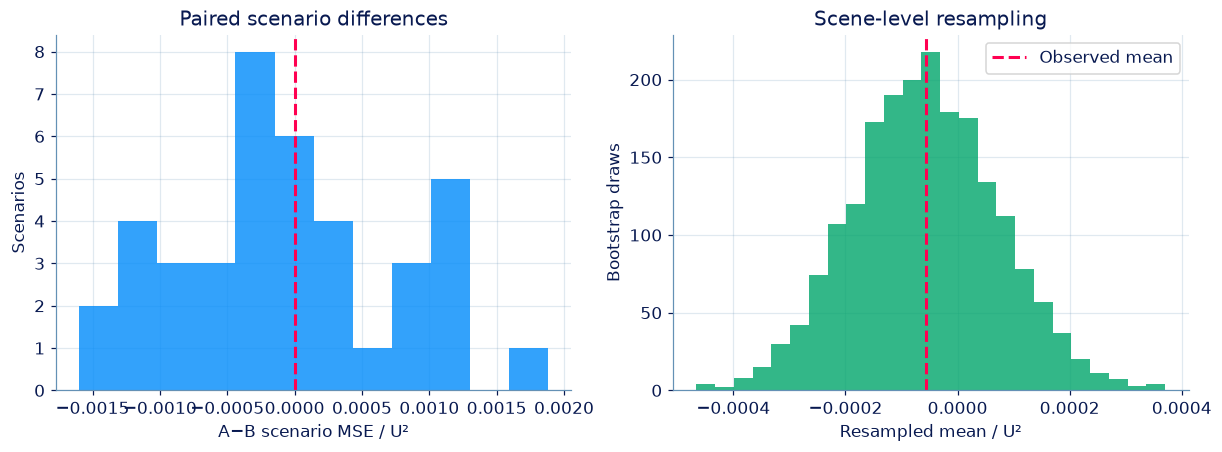

成功配对、失败对、平均差： 40 0 -6e-05
教学性95% bootstrap分位区间： [-0.00031  0.0002 ]


In [4]:
def scenario(seed,kp,ki,noise,disturbance):
    x=0.;I=0.;path=[x]
    for v,d in zip(noise,disturbance):
        _,u,I=pi_step(1.-(x+v),I,1.,kp,ki,1.)
        x=.9*x+.8*u+d;path.append(x)
    return np.mean((np.array(path)-1.)**2)
scores_a=[];scores_b=[]
for scenario_id in range(40):
    rng=np.random.default_rng(12000+scenario_id)
    v=rng.normal(0,.04,35);d=rng.normal(-.04,.03,35)
    scores_a.append(float(scenario(scenario_id,.6,.08,v,d)))
    scores_b.append(float(scenario(scenario_id,.8,.04,v,d)))
mean,failures,comparable=paired_difference(scores_a,scores_b)
diff=np.array(scores_a)-np.array(scores_b);bootstrap=np.random.default_rng(12099)
resampled=np.array([np.mean(bootstrap.choice(diff,size=len(diff),replace=True)) for _ in range(2000)])
fig,axes=plt.subplots(1,2,figsize=(11,4))
axes[0].hist(diff,bins=12,color=BLUE,alpha=.8);axes[0].axvline(0,color=PINK,ls='--');axes[0].set(xlabel='A−B scenario MSE / U²',ylabel='Scenarios',title='Paired scenario differences')
axes[1].hist(resampled,bins=25,color=GREEN,alpha=.8);axes[1].axvline(mean,color=PINK,ls='--',label='Observed mean');axes[1].set(xlabel='Resampled mean / U²',ylabel='Bootstrap draws',title='Scene-level resampling');axes[1].legend();plt.show()
print('成功配对、失败对、平均差：',comparable,failures,round(mean,5))
print('教学性95% bootstrap分位区间：',np.quantile(resampled,[.025,.975]).round(5))

## 结果解释

差值分布展示不同扰动下的表现变化；区间是对本例场景生成条件的抽样不确定性描述。即使两套PI在本例的平均差接近零，也不能断言二者等效；还需任务阈值、失败率、输入（input）代价和模型（model）外验证。

### 独立核对

把原始两列直接相减核对配对函数；在人工失败例中确认失败对没有被当成零误差。

In [5]:
np.testing.assert_allclose(mean,float(np.mean(diff)))
assert (failures,comparable)==(0,40)
assert paired_difference([1.,2.,None,4.],[2.,1.,3.,None])==(0.,2,2)
assert paired_difference([None],[1.])==(None,1,0)
print('逐场景差值、分母与失败边界一致。')

逐场景差值、分母与失败边界一致。


[在本章探索中改变条件](http://127.0.0.1:8000/chapters/10-07-%E4%BC%B0%E8%AE%A1%E5%8F%8D%E9%A6%88%E4%B8%8E%E9%97%AD%E7%8E%AF%E9%AA%8C%E8%AF%81/explore/)：先预测结果，再比较图形与数值。

## 练习与参考资料

先独立作答，再提交核对。

### 第 1 题 · Python 计算题：保留失败的配对比较

两个方法按相同顺序在同一组独立场景上得到指标；失败记None。返回两者都成功的指标差均值A−B、至少一方失败的场景数与可比场景数；不把失败默默计成零或删掉总分母。

**函数与代码模板**

```python
def solve(
    method_a: list[float | None],
    method_b: list[float | None],
) -> tuple[float | None, int, int]:
    # 按题意计算并返回结果。
    raise NotImplementedError("请完成计算")
```

**参数说明**

| 名称 | Python 类型 | 含义 | 单位 |
|---|---|---|---|
| `method_a` | <code>list[float &#124; None]</code> | A法每场景指标，失败为None。 | 题给指标单位 |
| `method_b` | <code>list[float &#124; None]</code> | B法同一批场景的指标。 | 题给指标单位 |

**返回值**

按以下顺序返回元组：(mean_difference, failed_pairs, comparable_pairs)。

| 名称 | Python 类型 | 含义 | 单位 |
|---|---|---|---|
| `mean_difference` | <code>float &#124; None</code> | 双方成功场景的平均A−B；若无可比项则None。 | 指标单位 |
| `failed_pairs` | `int` | 至少一方失败的配对场景数。 | 组 |
| `comparable_pairs` | `int` | 双方成功的场景数。 | 组 |

**计算规则**

逐位置配对。只在双方成功处计算差；仍报告全部场景中的失败配对数，便于联合解释。

**约束与边界**

- 两个列表等长，0—200组；非None数值有限。

**输入样例**

每个参数对应函数签名中的同名变量；单位与顺序见下表。

给定条件

| 参数 | 含义 | 给定值 | 单位 |
| --- | --- | --- | --- |
| method_a | A法每场景指标，失败为None。 | [1.0, 2.0, None, 4.0] | 题给指标单位 |
| method_b | B法同一批场景的指标。 | [2.0, 1.0, 3.0, None] | 题给指标单位 |

**输入与调用代码**

完成 solve 函数后，将下面的参数赋值与调用代码放在函数定义下方运行。

```python
method_a = [1.0, 2.0, None, 4.0]
method_b = [2.0, 1.0, 3.0, None]

result = solve(method_a, method_b)
print(result)
```

**输出样例**

对这组输入，你的函数应返回下列结果。列表按表格自上而下的顺序排列；标有“≈”的是便于阅读的近似值，请按模型计算完整数值。

计算结果

| 返回项 | 含义 | 结果 | 单位 |
| --- | --- | --- | --- |
| mean_difference | 双方成功场景的平均A−B；若无可比项则None。 | 0 | 指标单位 |
| failed_pairs | 至少一方失败的配对场景数。 | 2 | 组 |
| comparable_pairs | 双方成功的场景数。 | 2 | 组 |

**预期输出代码**

用 expected_output 对照 result 的类型、顺序与数值。代码保留样例原始精度，浮点结果按题面容差比较。

```python
expected_output = (0.0, 2, 2)
```

**样例解释**

首例成功配对差为−1与+1，平均0；但另有2组失败，不能仅凭平均0宣布两法等效。

允许 Python 标准库；绝对误差 1e-08 或相对误差 1e-07。

[作答：保留失败的配对比较](http://127.0.0.1:8000/chapters/10-07-%E4%BC%B0%E8%AE%A1%E5%8F%8D%E9%A6%88%E4%B8%8E%E9%97%AD%E7%8E%AF%E9%AA%8C%E8%AF%81/practice/?question=p10-paired-differences)

### 第 2 题 · 单项选择题：为什么按场景配对

为评估两个方法的平均误差差异，双方在同一批独立扰动场景上运行。重采样（resampling）不确定性时应怎样做？

- **A.** 以场景为单位重采样成对结果，保留每对差值。
- **B.** 分别打乱两法场景顺序再当成同一配对。
- **C.** 只重采样表现最好的几个场景。
- **D.** 重复读取同一场景并称其为新的独立实验。

[作答：为什么按场景配对](http://127.0.0.1:8000/chapters/10-07-%E4%BC%B0%E8%AE%A1%E5%8F%8D%E9%A6%88%E4%B8%8E%E9%97%AD%E7%8E%AF%E9%AA%8C%E8%AF%81/practice/?question=p10-paired-bootstrap)

### 第 3 题 · 单项选择题：失败率属于结果

方法A在40场景中失败8次，方法B失败0次；只在双方成功的32组里A略好。哪项最合理？

- **A.** 同时报告成功配对指标与A的8/40失败率；不同任务价值需要声明权衡。
- **B.** 删除8场景并声称A总体优于B。
- **C.** 把失败8次都算作0误差。
- **D.** 只看成功场景就证明A安全。

[作答：失败率属于结果](http://127.0.0.1:8000/chapters/10-07-%E4%BC%B0%E8%AE%A1%E5%8F%8D%E9%A6%88%E4%B8%8E%E9%97%AD%E7%8E%AF%E9%AA%8C%E8%AF%81/practice/?question=p10-failure-selection)

### 第 4 题 · 单项选择题：有限场景能说明多远

30组独立场景给出配对差的置信区间（confidence interval），但测试条件都只在很窄的扰动范围内。哪项正确？

- **A.** 区间只描述这些场景生成条件下的抽样不确定性，不能外推到未测试的大扰动。
- **B.** 有区间就证明任意生理对象都适用。
- **C.** 场景数量30意味着没有模型结构（model structure）误差。
- **D.** 区间越窄就证明传感器永不失效。

[作答：有限场景能说明多远](http://127.0.0.1:8000/chapters/10-07-%E4%BC%B0%E8%AE%A1%E5%8F%8D%E9%A6%88%E4%B8%8E%E9%97%AD%E7%8E%AF%E9%AA%8C%E8%AF%81/practice/?question=p10-uncertainty-scope)

**进一步阅读**

[MIT OpenCourseWare，Feedback Control Systems 课程讲义](https://ocw.mit.edu/courses/16-30-feedback-control-systems-fall-2010/pages/lecture-notes/)：按主题阅读 PID、频域、能控、观测器和线性二次调节；本教材的模型与数值为独立教学例。